In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scarf

scarf.set_verbosity('WARNING')

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name='kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)
stim_path = repository.download_dataset(
    name='kang_14K_ifnb-pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True
)

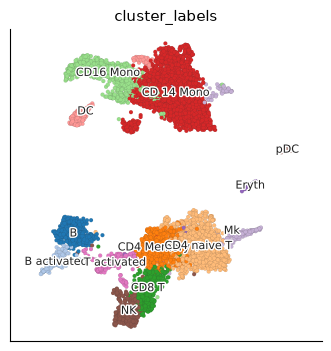

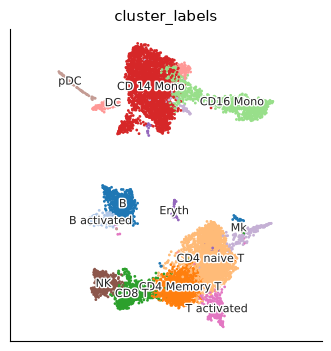

In [2]:
ds_ctrl = scarf.DataStore(f'{ctrl_path}/data.zarr', nthreads=4)
ds_stim = scarf.DataStore(f'{stim_path}/data.zarr', nthreads=4)

ds_ctrl.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
)
ds_stim.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cluster_labels',
)

In [3]:
ds_ctrl.run_mapping(
    target_assay=ds_stim.RNA,
    target_name='stim',
    target_feat_key='hvgs_ctrl',
    save_k=5
)
print(f"Mapped {ds_stim.cells.N} query cells onto the control reference")

Mapped 14446 query cells onto the control reference


Target cluster CD 14 Mono


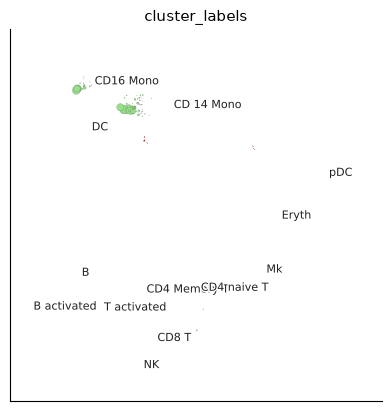

Target cluster NK


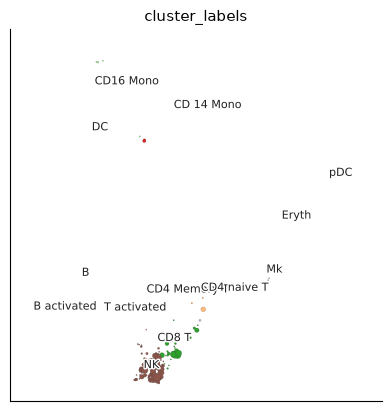

In [4]:
# Generate plots for IFN-B stimulated cells from NK and CD14 monocyte clusters.

for g, ms in ds_ctrl.get_mapping_score(
    target_name='stim',
    target_groups=ds_stim.cells.fetch('cluster_labels'),
    log_transform=True
):
    if g in ['NK', 'CD 14 Mono']:
        print(f"Target cluster {g}")
        ds_ctrl.plots.embedding(
            layout_key='RNA_UMAP',
            color_by='cluster_labels',
            point_sizes=ms * 10,
            figsize=(4, 4),
        )

In [5]:
transferred_labels = ds_ctrl.get_target_classes(
    target_name='stim',
    reference_class_group='cluster_labels'
)
transferred_labels.value_counts()

CD16 Mono       3920
CD4 naive T     1793
NA              1121
CD4 Memory T    1075
CD8 T            827
B                522
NK               365
T activated      149
B activated      143
Mk               106
Eryth             39
pDC               36
DC                 8
CD 14 Mono         7
Name: count, dtype: int64

In [6]:
evidence = ds_ctrl.get_target_label_evidence(
    target_name='stim',
    reference_class_group='cluster_labels',
    threshold_fraction=0.6
)
evidence.head()

,label,voteFraction,voteEntropy,topTwoMargin,featureCoverage,referenceDistancePercentile,isUnknown
0,CD8 T,0.802183,0.497362,0.604366,1.0,0.239904,False
1,pDC,1.000000,-0.000000,1.000000,1.0,0.384644,False
2,CD4 naive T,1.000000,-0.000000,1.000000,1.0,0.255149,False
3,B,1.000000,-0.000000,1.000000,1.0,0.307745,False
4,NA,0.584268,0.678877,0.168536,1.0,0.235866,True


In [7]:
ds_stim.cells.insert(
    'transferred_labels',
    transferred_labels.values,
    overwrite=True
)

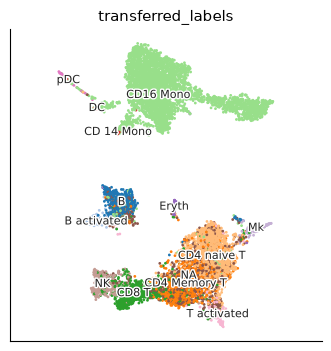

In [8]:
ds_stim.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='transferred_labels',
)

In [9]:
import pandas as pd

df = pd.crosstab(
    ds_stim.cells.fetch('cluster_labels'),
    ds_stim.cells.fetch('transferred_labels')
)
df

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,495,5,0,78,13,2,2,0,0,3,146,0,1,1
B activated,24,138,0,11,2,0,0,0,0,0,28,1,1,0
CD 14 Mono,0,0,5,2527,0,0,0,0,0,0,0,0,0,0
CD16 Mono,0,0,0,956,0,0,0,0,0,0,0,0,0,0
CD4 Memory T,0,0,0,8,668,102,118,0,0,1,399,0,1,0
CD4 naive T,3,0,0,17,335,1600,16,0,0,0,412,2,5,0
CD8 T,0,0,0,1,12,2,588,0,0,0,27,24,1,0
DC,0,0,0,204,1,0,0,8,0,0,1,0,0,0
Eryth,0,0,0,15,9,16,2,0,38,0,3,0,0,0


In [10]:
(100 * df / df.sum(axis=0)).round(1)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,94.8,3.5,0.0,2.0,1.2,0.1,0.2,0.0,0.0,2.8,13.0,0.0,0.7,2.8
B activated,4.6,96.5,0.0,0.3,0.2,0.0,0.0,0.0,0.0,0.0,2.5,0.3,0.7,0.0
CD 14 Mono,0.0,0.0,71.4,64.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD16 Mono,0.0,0.0,0.0,24.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD4 Memory T,0.0,0.0,0.0,0.2,62.1,5.7,14.3,0.0,0.0,0.9,35.6,0.0,0.7,0.0
CD4 naive T,0.6,0.0,0.0,0.4,31.2,89.2,1.9,0.0,0.0,0.0,36.8,0.5,3.4,0.0
CD8 T,0.0,0.0,0.0,0.0,1.1,0.1,71.1,0.0,0.0,0.0,2.4,6.6,0.7,0.0
DC,0.0,0.0,0.0,5.2,0.1,0.0,0.0,100.0,0.0,0.0,0.1,0.0,0.0,0.0
Eryth,0.0,0.0,0.0,0.4,0.8,0.9,0.2,0.0,97.4,0.0,0.3,0.0,0.0,0.0


In [11]:
matches = ds_stim.cells.fetch('cluster_labels') == transferred_labels.to_numpy()
print(f'Labels matching the stored target label: {100 * matches.mean():.1f}%')

Labels matching the stored target label: 50.5%


In [12]:
evidence_for_cal = ds_ctrl.get_target_label_evidence(
    target_name='stim',
    reference_class_group='cluster_labels',
    threshold_fraction=0.0,
)
correct = (
    ds_stim.cells.fetch('cluster_labels') == transferred_labels.to_numpy()
)
calibration = ds_ctrl.calibrate_label_transfer_threshold(
    vote_fractions=evidence_for_cal['voteFraction'].to_numpy(dtype=float),
    correct=np.asarray(correct, dtype=bool),
    target_coverage=0.9,
)
calibration

{'voteThreshold': 0.6038504265692206,
 'validationCoverage': 0.7930966274354663,
 'validationAccuracy': 0.5732634991894251}

In [13]:
ds_ctrl.run_unified_umap(
    target_names=['stim'],
    ini_embed_with='RNA_UMAP',
    target_weight=1,
    use_k=5,
    n_epochs=100
)

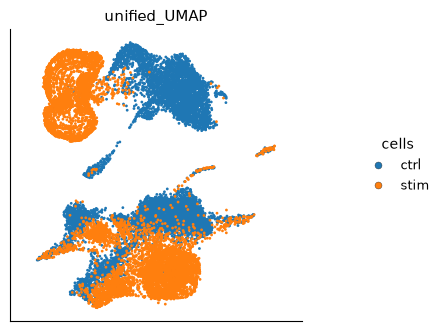

In [14]:
ds_ctrl.plots.unified_embedding(
    layout_key='unified_UMAP',
    ref_name='ctrl',
)

In [15]:
projected_layout = ds_ctrl.project_mapping_layout(
    target_name='stim',
    reference_layout_key='RNA_UMAP'
)

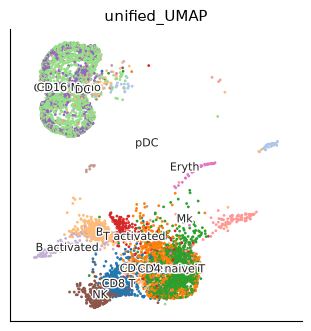

In [16]:
ds_ctrl.plots.unified_embedding(
    layout_key='unified_UMAP',
    show_target_only=True,
    target_groups=ds_stim.cells.fetch('cluster_labels'),
    legend_loc='on_data',
)

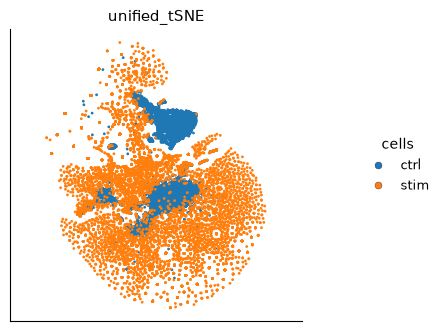

In [17]:
ds_ctrl.run_unified_tsne(
    target_names=['stim'],
    ini_embed_with='RNA_UMAP',
    target_weight=1,
    use_k=5,
    max_iter=500,
    verbose=False,
)

ds_ctrl.plots.unified_embedding(
    layout_key='unified_tSNE',
    ref_name='ctrl',
)

In [18]:
ds_ctrl.cells.insert(
    'reference_batch',
    np.repeat('control', ds_ctrl.cells.N),
    overwrite=True
)

reference = ds_ctrl.build_mapping_reference(
    feat_key='hvgs',
    batch_columns=['reference_batch']
)

In [19]:
reference = ds_ctrl.get_mapping_reference(feat_key='hvgs')

In [20]:
result = reference.map_query(
    target_assay=ds_stim.RNA,
    target_name='stim_symphony',
    target_feat_key='hvgs_symphony',
    save_k=5,
    query_batches=pd.DataFrame(
        {
            'reference_batch': np.repeat(
                'stimulated',
                len(ds_stim.cells.fetch('ids', key='I'))
            )
        }
    )
)
result

MappingResult(n_cells=10111, correction_method='symphony', diagnostics={'featureCoverage': 1.0, 'queryBatchCount': 1.0, 'zeroNormCellCount': 0.0, 'algorithmVariant': 'symphony'}, arrays=not loaded, projection_path='RNA/artifacts/projection/df79bc8e31a615c...')

In [21]:
mapped = ds_ctrl.get_mapping_result('stim_symphony', load_arrays=True)
mapped.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1.0,
 'algorithmVariant': 'symphony'}

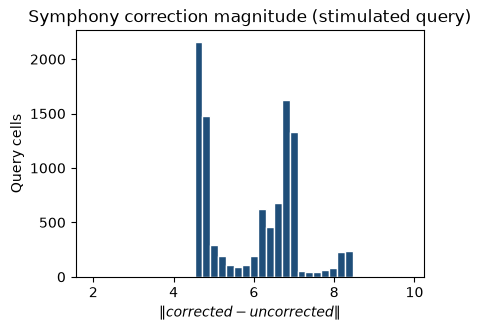

In [22]:
shift = np.linalg.norm(
    mapped.corrected_latent - mapped.uncorrected_latent,
    axis=1,
)

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(shift, bins=40, color='#1f4e79', edgecolor='white')
ax.set_xlabel(r'$\|corrected - uncorrected\|$')
ax.set_ylabel('Query cells')
ax.set_title('Symphony correction magnitude (stimulated query)')
fig

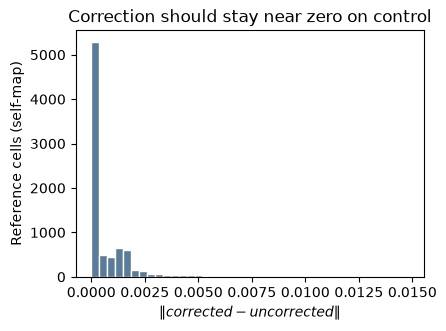

In [23]:
control_result = reference.map_query(
    target_assay=ds_ctrl.RNA,
    target_name='control_symphony',
    target_feat_key='hvgs_control_symphony',
    save_k=5,
    query_batches=pd.DataFrame(
        {'reference_batch': ds_ctrl.cells.fetch('reference_batch', key='I')}
    )
)
control_mapped = ds_ctrl.get_mapping_result(
    'control_symphony',
    load_arrays=True,
)
ctrl_shift = np.linalg.norm(
    control_mapped.corrected_latent - control_mapped.uncorrected_latent,
    axis=1,
)

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(ctrl_shift, bins=40, color='#5b7c99', edgecolor='white')
ax.set_xlabel(r'$\|corrected - uncorrected\|$')
ax.set_ylabel('Reference cells (self-map)')
ax.set_title('Correction should stay near zero on control')
fig

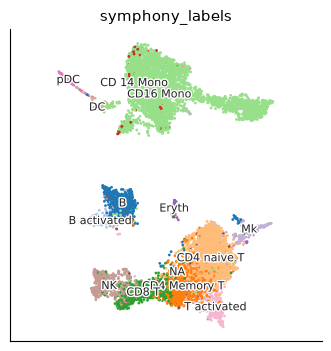

In [24]:
transferred = ds_ctrl.get_target_classes(
    target_name='stim_symphony',
    reference_class_group='cluster_labels',
)
ds_stim.cells.insert('symphony_labels', transferred.values, overwrite=True)

ds_stim.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='symphony_labels',
)

In [25]:
pd.crosstab(
    ds_stim.cells.fetch('cluster_labels'),
    ds_stim.cells.fetch('symphony_labels'),
)

col_0,B,B activated,CD 14 Mono,CD16 Mono,CD4 Memory T,CD4 naive T,CD8 T,DC,Eryth,Mk,NA,NK,T activated,pDC
row_0,,,,,,,,,,,,,,
B,669,16,0,22,6,3,0,0,0,6,16,2,5,1
B activated,15,180,0,1,0,0,0,0,0,0,6,2,1,0
CD 14 Mono,0,0,59,2473,0,0,0,0,0,0,0,0,0,0
CD16 Mono,0,0,0,955,0,0,0,0,0,1,0,0,0,0
CD4 Memory T,5,0,1,12,861,175,189,0,0,3,33,1,17,0
CD4 naive T,9,4,1,21,243,2030,18,0,0,9,19,3,33,0
CD8 T,0,0,0,3,4,1,437,0,0,0,5,202,3,0
DC,0,0,1,163,0,0,0,50,0,0,0,0,0,0
Eryth,0,0,0,13,1,21,1,0,46,0,1,0,0,0


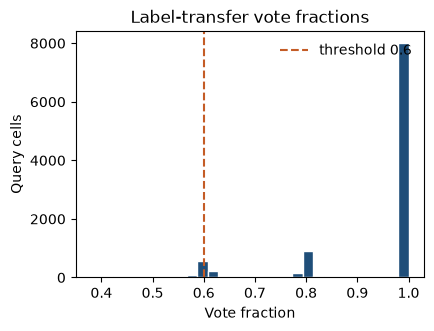

In [26]:
symphony_evidence = ds_ctrl.get_target_label_evidence(
    target_name='stim_symphony',
    reference_class_group='cluster_labels',
    threshold_fraction=0.6
)

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(
    symphony_evidence['voteFraction'].dropna(),
    bins=30,
    color='#1f4e79',
    edgecolor='white',
)
ax.axvline(0.6, color='#c45c26', linestyle='--', label='threshold 0.6')
ax.set_xlabel('Vote fraction')
ax.set_ylabel('Query cells')
ax.set_title('Label-transfer vote fractions')
ax.legend(frameon=False)
fig